<a href="https://colab.research.google.com/github/marcus-muniz/NN_from_scratch/blob/main/neural_networks_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

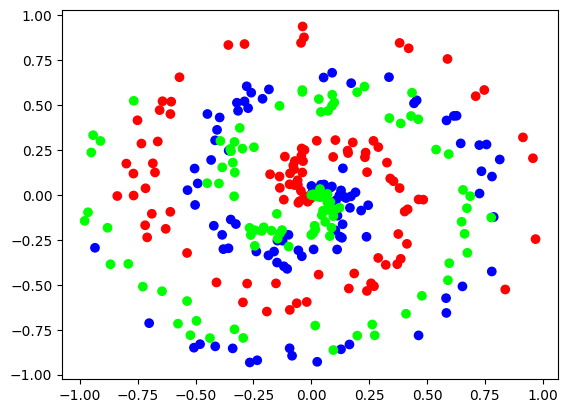

In [1]:
import numpy as np
!pip install nnfs
from nnfs.datasets import spiral_data
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

In [2]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2]


In [ ]:

### 1 Layer
inputs=np.array([[1, 2, 3, 2.5],
                 [2., 5., -1., 2.],
                 [-1.5, 2.7, 3.3, -.8]])

weights=np.array([[0.2, 0.8, -0.5, 1.0],
         [0.5, -.91, .26, -.5],
         [-0.26, -.27, 0.17, 0.87]])
bias=np.array([[2, 3, 0.5]])
output=np.dot(inputs, np.array(weights).T)+bias
print(output)


[[ 4.79999995  1.21000004  2.38499999]
 [ 8.9000001  -1.80999994  0.19999999]
 [ 1.41000003  1.051       0.02599999]]


In [ ]:
### 2 layers
import numpy as np
inputs=np.array([[1, 2, 3, 2.5],
                 [2., 5., -1., 2.],
                 [-1.5, 2.7, 3.3, -.8]])

weights=np.array([[0.2, 0.8, -0.5, 1.0],
         [0.5, -.91, .26, -.5],
         [-0.26, -.27, 0.17, 0.87]])
weights2=np.array([[0.1, -0.14, 0.5],
         [-0.5, 0.12, -0.33],
         [-0.44, 0.73, -0.13]])
biases=np.array([[2, 3, 0.5]])
biases2=np.array([[-1, 2, -.5]])
layer1_outputs=np.dot(inputs, np.array(weights).T)+biases
layer2_outputs=np.dot(layer1_outputs, np.array(weights2).T)+biases2
print(layer2_outputs)


[[ 0.50310004 -1.04184985 -2.03874993]
 [ 0.24339998 -2.73320007 -5.76329994]
 [-0.99314     1.41254002 -0.35655001]]


In [ ]:
class Layer_Dense:
# Layer initialisation
  def __init__(self, n_inputs, n_neurons):
    self.weights=.01*np.random.randn(n_inputs, n_neurons)
    self.biases = np.zeros((1,n_neurons))
  def forward(self, inputs):
    # Calculate output values from inputs, weights and biases
    self.output = np.dot(inputs, self.weights) + self.biases

# ReLU activation
class Activation_ReLU:

  # Forward pass
  def forward(self, inputs):
    # Calculate output values from inputs
    self.output=np.maximum(0,inputs)

# Softmax activation
class Activation_Softmax:
  # Forward pass
  def forward(self, inputs):

    # Get unnormalisd probabilities
    exp_values=np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

    # Normalise for each sample
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)

    self.output = probabilities

# Create dataset
X, y = spiral_data(samples=100, classes=3)
#print(X.shape)
#print(X[0:3,:])

# Dense layer with 2 input features (shoud be the x,y coordinates in the array X
# and 3 output values)
dense1=Layer_Dense(2,3)

# Create ReLU ativiation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Dense layer 2 with 3 inputs from the previous layer and output values
dense2=Layer_Dense(3,3)

# Create Softmax activation (to be used with Dense layer)
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])




[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.3333333  0.33333334]
 [0.3333335  0.333333   0.33333352]
 [0.33333334 0.33333334 0.33333334]]


In [ ]:
import numpy as np
softmax_outputs = np.array([[0.7, .1, .2],
                            [.1, .5, .4],
                            [0.02, .9, .08]])
# Sparse
class_targets = np.array([[1, 0, 0],
                          [0, 1, 0],
                          [0, 1, 0]])
# One-hot
#class_targets = np.array([0, 1, 1])


if len(class_targets.shape) == 1:
  print("one-hot")
  correct_confidences = softmax_outputs[range(len(softmax_outputs)),
                                        class_targets]
elif len(class_targets.shape)==2:
  print("sparse")
  correct_confidences=np.sum(softmax_outputs*class_targets, axis=1)

neg_loss =-np.log(correct_confidences)
average_loss=np.mean(neg_loss)
print(average_loss)


sparse
0.38506088005216804


# Chapter 9 - Full Code

In [ ]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

#Dense Layer
class Layer_Dense:

  # Layer initialisation
  def __init__(self, n_inputs, n_neurons):
    # Initialise weights and biases
    self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
    self.biases = np.zeros((1,n_neurons))

  # Forward pass
  def forward(self, inputs):
    # Remember input values
    self.inputs = inputs
    # Calculate output values from inputs, weights and biases
    self.output = np.dot(inputs, self.weights) + self.biases

  # Backward pass
  def backward(self, dvalues):
    # Gradients on parameters
    self.dweights = np.dot(self.inputs.T, dvalues)
    self.dbiases = np.sum(dvalues, axis=0, keepdims= True)
    # Gradient on values
    self.dinputs = np.dot(dvalues, self.weights.T)

#ReLU activation
class Activation_ReLU:

  # Forward pass
  def forward(self, inputs):
    # Remember input values
    self.inputs = inputs
    # Calculate output values from inputs
    self.output=np.maximum(0, inputs)

  # Backward pass
  def backward(self, dvalues):
    # Since we need to modify original variable, let's make a copy of values first
    self.dinputs = dvalues.copy()

    # Zero gradient where input values were negative
    self.dinputs[self.inputs<=0] = 0

# Softmax activation
class Activation_Softmax:

  #Forward pass
  def forward(self, inputs):
    #Remember input values
    self.inputs=inputs

    # Get unnormalised probabilities
    exp_values=np.exp(inputs-np.max(inputs, axis=1, keepdims=True))

    # Normalise them for each sample
    probabilities = exp_values/np.sum(exp_values, axis=1, keepdims=True)
    self.output = probabilities

  #Backward pass
  def backward(self, dvalues):

    # Create unitialised array
    self.dinputs = np.empty_like(dvalues)

    # Eunmerate outputs and gradients
    for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
      # Flatten output array
      single_output = single_output.reshape(-1,1)
      # Calculate Jacobian matrix of the output
      jacobian_matrix = np.diagflat(single_output)- np.dot(single_output, single_output.T)
      # Calculate sample-wise gradient and add it to the array of sample gradients
      self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

# Common loss class
class Loss:

  # Calculates the data and regularisation losses given model output and ground thruth values
  def calculate(self, output, y):
    #Calculate sample losses
    sample_losses= self.forward(output,y)

    # Calculate mean loss
    data_loss = np.mean(sample_losses)

    return data_loss

  # Cross-entropy loss

class Loss_CategoricalCrossentropy(Loss):

  # Forward pass
  def forward(self, y_pred, y_true):

    #Number of samples in a batch
    samples = len(y_pred)

    # Clip data to prevent division by 0
    # Clip both sides to not drag mean towqards any value
    y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)

    # Probabilities for target values - only if categorical label
    if len(y_true.shape) == 1:
      correct_confidences = y_pred_clipped[range(samples), y_true]

    # Mask values - only for one-hot encoded labels
    elif len(y_true.shape) == 2:
      correct_confidences = np.sum(y_pred_clipped*y_true, axis=1)

    # Losses
    negative_log_likelihoods = -np.log(correct_confidences)
    return negative_log_likelihoods

  def backward(self, dvalues, y_true):
    # number of samples
    samples = len(dvalues)
    # Number of labels in every sample. We'll use the first sample to count them
    labels = len(dvalues[0])

    # If labels are sparse, turn them into one-hot vector
    if len(y_true.shape) == 1:
      y_true = np.eye(labels)[y_true]

    # Calculate gradient
    self.dinputs = -y_true/dvalues
    # Normalize gradient
    self.dinputs = self.dinputs/samples
# Softmax classifier
class Activation_Softmax_Loss_CategoricalCrossentropy():

  # Creates activation and loss function objects
  def __init__(self):
    self.activation = Activation_Softmax()
    self.loss = Loss_CategoricalCrossentropy()

  # Forward pass
  def forward(self, inputs, y_true):
    # Output layer's activation function
    self.activation.forward(inputs)
    # Set the output
    self.output = self.activation.output
    # Calculate and return loss value
    return self.loss.calculate(self.output, y_true)

  # Backward pass
  def backward(self, dvalues, y_true):

    # Number of samples
    samples = len(dvalues)

    # If labels are one-hot encode turn them into discret values
    if len(y_true.shape) == 2:
      y_true = np.argmax(y_true, axis=1)

    # Copy so we can safely modify
    self.dinputs = dvalues.copy()
    # Calculate gradient
    self.dinputs[range(samples), y_true] -= 1
    # Normalize gradient
    self.dinputs = self.dinputs/samples



# Create dataset
X, y =spiral_data(samples=100, classes=3)

# Create Dense Layer with 2 input features (spatial coordinates contained in X)
# and 3 output values
dense1 = Layer_Dense(2,3)

# Create ReLU activation (to be used with Dense Layer
activation1 = Activation_ReLU()

# Create second Dense layer with 3 input features and 3 output valuews
dense2= Layer_Dense(3,3)

# Create Softmax classifiers combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Perform a forward pass on our training data through this layer
dense1.forward(X)

# Perform a forward pass through activation function
activation1.forward(dense1.output)

# Performa a forward pass throough second Dense layer
dense2.forward(activation1.output)

# Perform a forwawrd pass through the activation/loss function
loss = loss_activation.forward(dense2.output, y)

print(loss_activation.output[:5])
print('loss:', loss)

# Calculate accuracy from output of activation2 and targets
predications = np.argmax(loss_activation.output, axis=1)
if len(y.shape) == 2:
  y=np.argmax(y, axis=1)

accuracy = np.mean(predications == y)
print('acc:', accuracy)

# Backward pass
loss_activation.backward(loss_activation.output, y)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

# Print gradients
print(dense1.dweights)
print(dense1.dbiases)
print(dense2.dweights)
print(dense2.dbiases)
#


[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]
loss: 1.0986104
acc: 0.34
[[ 1.5766357e-04  7.8368583e-05  4.7324400e-05]
 [ 1.8161038e-04  1.1045573e-05 -3.3096312e-05]]
[[-3.60553473e-04  9.66117223e-05 -1.03671395e-04]]
[[ 5.44109462e-05  1.07411419e-04 -1.61822361e-04]
 [-4.07913431e-05 -7.16780924e-05  1.12469446e-04]
 [-5.30112993e-05  8.58172934e-05 -3.28059905e-05]]
[[-1.0729185e-05 -9.4610732e-06  2.0027859e-05]]


# Chapter 10

In [ ]:
# Optimiser pass 1

class Optimizer_SGD:
  # Initilise optimiser - set settings, learning rate of 1, is default for this optimizer
  def __init__(self, learning_rate=1.0):
    self.learning_rate=learning_rate

  def update_params(self,layer):
    layer.weights += -self.learning_rate*layer.dweights
    layer.biases += -self.learning_rate*layer.dbiases

optimizer=Optimizer_SGD()
optimizer.update_params(dense1)
optimizer.update_params(dense2)

X,y = spiral_data(samples=100, classes=3)
dense1=Layer_Dense(2,64)
activation1=Activation_ReLU()
dense2=Layer_Dense(64,3)
loss_activation=Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer=Optimizer_SGD()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
loss=loss_activation.forward(dense2.output, y)
print("loss: ", loss)

predictions = np.argmax(loss_activation.output, axis=1)

if len(y.shape)==2:
  y=np.argmax(y, axis = 1)
accuracy = np.mean(predictions == y)
print("acc", accuracy)

loss_activation.backward(loss_activation.output, y)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

optimizer.update_params(dense1)
optimizer.update_params(dense2)


loss:  1.0985887
acc 0.35


epoch: 0, acc: 0.347, loss: 1.099
epoch: 100, acc: 0.400, loss: 1.093
epoch: 200, acc: 0.407, loss: 1.070
epoch: 300, acc: 0.417, loss: 1.066
epoch: 400, acc: 0.410, loss: 1.064
epoch: 500, acc: 0.417, loss: 1.062
epoch: 600, acc: 0.420, loss: 1.061
epoch: 700, acc: 0.420, loss: 1.060
epoch: 800, acc: 0.420, loss: 1.059
epoch: 900, acc: 0.420, loss: 1.058
epoch: 1000, acc: 0.423, loss: 1.056
epoch: 1100, acc: 0.420, loss: 1.055
epoch: 1200, acc: 0.423, loss: 1.052
epoch: 1300, acc: 0.420, loss: 1.049
epoch: 1400, acc: 0.430, loss: 1.044
epoch: 1500, acc: 0.450, loss: 1.037
epoch: 1600, acc: 0.447, loss: 1.030
epoch: 1700, acc: 0.487, loss: 1.022
epoch: 1800, acc: 0.507, loss: 1.014
epoch: 1900, acc: 0.517, loss: 1.006
epoch: 2000, acc: 0.510, loss: 0.999
epoch: 2100, acc: 0.510, loss: 0.991
epoch: 2200, acc: 0.517, loss: 0.984
epoch: 2300, acc: 0.507, loss: 0.994
epoch: 2400, acc: 0.483, loss: 0.995
epoch: 2500, acc: 0.507, loss: 0.991
epoch: 2600, acc: 0.497, loss: 0.987
epoch: 2700, 

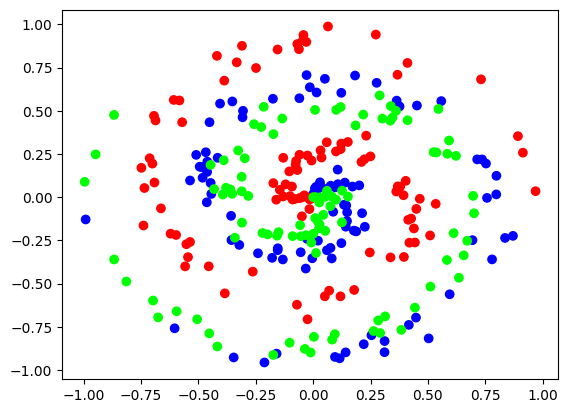

In [ ]:
# Optimiser Loop

class Optimizer_SGD:
  # Initilise optimiser - set settings, learning rate of 1, is default for this optimizer
  def __init__(self, learning_rate=0.5):
    self.learning_rate=learning_rate

  def update_params(self,layer):
    layer.weights += -self.learning_rate*layer.dweights
    layer.biases += -self.learning_rate*layer.dbiases

optimizer=Optimizer_SGD()
optimizer.update_params(dense1)
optimizer.update_params(dense2)

X,y = spiral_data(samples=100, classes=3)
dense1=Layer_Dense(2,64)
activation1=Activation_ReLU()
dense2=Layer_Dense(64,3)
loss_activation=Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer=Optimizer_SGD()

for epoch in range(10001):
  dense1.forward(X)
  activation1.forward(dense1.output)
  dense2.forward(activation1.output)
  loss=loss_activation.forward(dense2.output, y)


  predictions = np.argmax(loss_activation.output, axis=1)

  if len(y.shape)==2:
    y=np.argmax(y, axis = 1)
  accuracy = np.mean(predictions == y)

  if not epoch %100:
    print(f'epoch: {epoch}, ' +
          f'acc: {accuracy:.3f}, ' +
          f'loss: {loss:.3f}')

  #Backward pass
  loss_activation.backward(loss_activation.output, y)
  dense2.backward(loss_activation.dinputs)
  activation1.backward(dense2.dinputs)
  dense1.backward(activation1.dinputs)

  optimizer.update_params(dense1)
  optimizer.update_params(dense2)



plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

Shape of XX_x (x-coordinates): (1000, 1000)
Shape of XX_y (y-coordinates): (1000, 1000)
Final shape of combined XX: (1000000, 2)


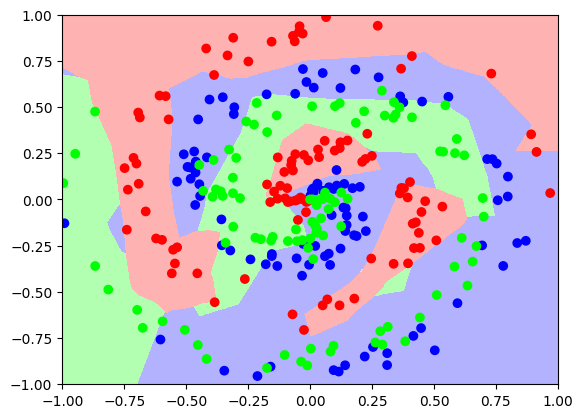

In [ ]:
x_coords_1d = np.linspace(-1, 1, 1000)
y_coords_1d = np.linspace(-1, 1, 1000)
XX_x, XX_y = np.meshgrid(x_coords_1d, y_coords_1d)

print(f"Shape of XX_x (x-coordinates): {XX_x.shape}")
print(f"Shape of XX_y (y-coordinates): {XX_y.shape}")

# Flatten XX_x and XX_y, then stack them column-wise
XX_combined = np.column_stack((XX_x.ravel(), XX_y.ravel()))

print(f"Final shape of combined XX: {XX_combined.shape}")

# Assign the combined array back to XX if you wish to use this format later
XX = XX_combined

#XX=np.array([np.linspace(-1,1,100), np.linspace(-1,1,100)])
#XX = np.meshgrid(XX[:,0], XX[:,1])
#XX=XX.T
#XX.shape
dense1.forward(XX)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
YY=np.zeros(len(XX), dtype=int)

loss_activation.forward(dense2.output, YY)
YY = np.argmax(loss_activation.output, axis=1)

# Reshape YY back to a 2D grid for contour plotting
YY_reshaped = YY.reshape(XX_x.shape)

# Plot the background grid classification as filled areas using pcolormesh
plt.pcolormesh(XX_x, XX_y, YY_reshaped, cmap='brg', alpha=0.3, shading='auto')

# Then plot the original data points on top
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

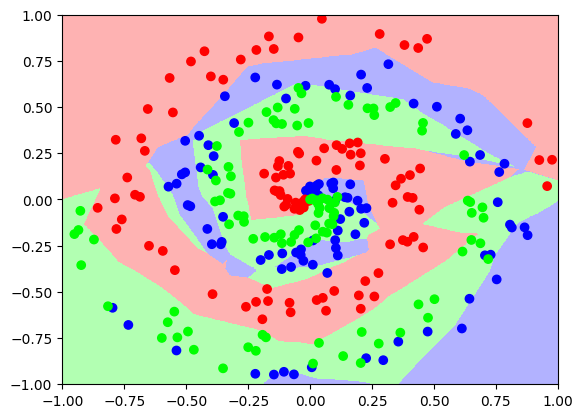

In [ ]:
# Plot the background grid classification as filled areas using pcolormesh
plt.pcolormesh(XX_x, XX_y, YY_reshaped, cmap='brg', alpha=0.3, shading='auto')

# Then plot the original data points on top
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

# Using Pytorch CPU

tensor(1.1190, grad_fn=<NllLossBackward0>)
epoch: 0 loss 1.1190
epoch: 1000 loss 0.9437
epoch: 2000 loss 0.8205
epoch: 3000 loss 0.6715
epoch: 4000 loss 0.6037
epoch: 5000 loss 0.8539
epoch: 6000 loss 0.5255
epoch: 7000 loss 0.9095
epoch: 8000 loss 0.5103
epoch: 9000 loss 0.4452

>>> Training completed in: 232.0503 seconds <<<


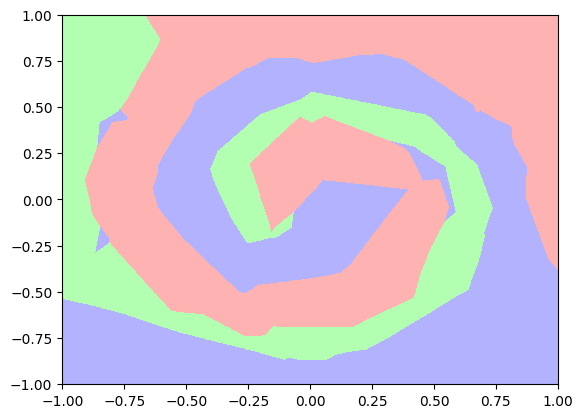

In [7]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from nnfs.datasets import spiral_data
import torch.optim as optim
import numpy as np
import time
start_time = time.perf_counter()

X, y = spiral_data(samples=10000, classes=3)
X=torch.tensor(X, dtype=torch.float32)
y=torch.tensor(y)

class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1=nn.Linear(2,64)
    self.fc2=nn.Linear(64,3)

  def forward(self, input):
    c1=F.relu(self.fc1(input))
    c2=self.fc2(c1)
    return c2

net=Net()
output = net(X)
criterion = nn.CrossEntropyLoss()
loss = criterion(output, y)
print(loss)


optimizer = optim.SGD(net.parameters(), lr=0.9)
for i in range(10000):
# in your training loop:
    optimizer.zero_grad()   # zero the gradient buffers
    output = net(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()    # Does the update
    if i % 1000 == 0:
        print(f'epoch: {i} loss {loss.item():.4f}')


end_time = time.perf_counter()

# Calculate the difference
total_time = end_time - start_time
print(f"\n>>> Training completed in: {total_time:.4f} seconds <<<")

# --- 1. Your Meshgrid Setup ---
x_coords_1d = np.linspace(-1, 1, 1000)
y_coords_1d = np.linspace(-1, 1, 1000)
XX_x, XX_y = np.meshgrid(x_coords_1d, y_coords_1d)

# Flatten XX_x and XX_y, then stack them column-wise
XX_combined = np.column_stack((XX_x.ravel(), XX_y.ravel()))
XX = XX_combined

# --- 2. PyTorch Inference ---
# Convert the NumPy grid to a PyTorch tensor
XX_tensor = torch.tensor(XX, dtype=torch.float32)

# Set model to evaluation mode (best practice, turns off things like Dropout if you add them later)
net.eval()

# Use torch.no_grad() because we don't need to calculate gradients for plotting.
# This makes it run much faster and uses less memory.
with torch.no_grad():
    # Pass the grid through the network
    grid_outputs = net(XX_tensor)

    # Get the predicted class (0, 1, or 2)
    grid_predictions = torch.argmax(grid_outputs, dim=1)

# Convert the PyTorch tensor back to a NumPy array for matplotlib
# (Using .cpu() just in case you ever move this code to a GPU!)
YY = grid_predictions.cpu().numpy()

# --- 3. Your Plotting Code ---
# Reshape YY back to a 2D grid for contour plotting
YY_reshaped = YY.reshape(XX_x.shape)

# Plot the background grid classification as filled areas
plt.pcolormesh(XX_x, XX_y, YY_reshaped, cmap='brg', alpha=0.3, shading='auto')

# Plot the original data points on top
# Note: Because your original X and y are currently PyTorch tensors,
# you MUST add .numpy() here so matplotlib can read them!
#plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=y.numpy(), cmap='brg', edgecolors='k')

plt.show()


# Using Pytorch on cuda

Using device: cuda
Initial loss: 1.0948
epoch: 0 loss 1.0948
epoch: 1000 loss 0.9177
epoch: 2000 loss 0.7189
epoch: 3000 loss 0.6511
epoch: 4000 loss 0.5423
epoch: 5000 loss 0.5188
epoch: 6000 loss 0.4744
epoch: 7000 loss 0.4484
epoch: 8000 loss 0.4411
epoch: 9000 loss 0.4204

>>> Training completed in: 15.4410 seconds <<<


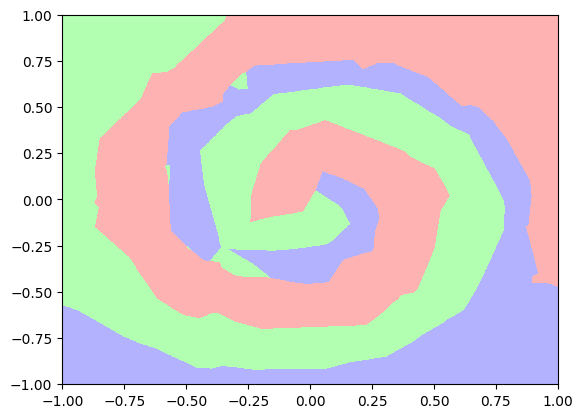

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from nnfs.datasets import spiral_data
import torch.optim as optim
import numpy as np
import time
start_time = time.perf_counter()
# --- NEW: Step 1 - Define the device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X, y = spiral_data(samples=10000, classes=3)

# --- NEW: Step 2 - Move training data to device ---
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.long).to(device) # ensure labels are long integers

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, input):
        c1 = F.relu(self.fc1(input))
        c2 = self.fc2(c1)
        return c2

# --- NEW: Step 3 - Move the model to device ---
net = Net().to(device)

output = net(X)
criterion = nn.CrossEntropyLoss()
loss = criterion(output, y)
print(f"Initial loss: {loss.item():.4f}")

optimizer = optim.SGD(net.parameters(), lr=0.9)
for i in range(10000):
    optimizer.zero_grad()
    output = net(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
        print(f'epoch: {i} loss {loss.item():.4f}')

end_time = time.perf_counter()

# Calculate the difference
total_time = end_time - start_time
print(f"\n>>> Training completed in: {total_time:.4f} seconds <<<")
# --- 1. Your Meshgrid Setup ---
x_coords_1d = np.linspace(-1, 1, 1000)
y_coords_1d = np.linspace(-1, 1, 1000)
XX_x, XX_y = np.meshgrid(x_coords_1d, y_coords_1d)

XX_combined = np.column_stack((XX_x.ravel(), XX_y.ravel()))
XX = XX_combined

# --- 2. PyTorch Inference ---
# --- NEW: Step 4 - Move inference data to device ---
XX_tensor = torch.tensor(XX, dtype=torch.float32).to(device)

net.eval()

with torch.no_grad():
    grid_outputs = net(XX_tensor)
    grid_predictions = torch.argmax(grid_outputs, dim=1)

# Bring predictions back to CPU for Matplotlib (We already had this in place!)
YY = grid_predictions.cpu().numpy()

# --- 3. Your Plotting Code ---
YY_reshaped = YY.reshape(XX_x.shape)

plt.pcolormesh(XX_x, XX_y, YY_reshaped, cmap='brg', alpha=0.3, shading='auto')

# --- NEW: Step 5 - Bring X and y back to CPU for plotting ---
# Because X and y were moved to the GPU at the top of the script,
# matplotlib will crash unless we call .cpu() before .numpy()
#plt.scatter(X.cpu().numpy()[:, 0], X.cpu().numpy()[:, 1], c=y.cpu().numpy(), cmap='brg', edgecolors='k')

plt.show()

In [2]:
torch.cuda.is_available()

True